## Into to pyspark

### Reading the data as Spark Dataframe 
### 



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [1]:
import os
import subprocess

# Jupyter kernels launched from an IDE/GUI don't source ~/.zshrc, so JAVA_HOME
# may be missing even if it's set in your shell profile. Resolve it via brew
# directly so this works regardless of how the kernel was started.
if "JAVA_HOME" not in os.environ:
    os.environ["JAVA_HOME"] = subprocess.check_output(["brew", "--prefix", "openjdk@17"], text=True).strip()
os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin:" + os.environ.get("PATH", "")

from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("pyspark-demo").master("local[*]").getOrCreate()
spark.sparkContext.setLogLevel("ERROR")
spark

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/08/30 21:40:05 WARN Utils: Your hostname, Andriis-MacBook-Pro-2.local, resolves to a loopback address: 127.0.0.1; using 192.168.0.142 instead (on interface en0)
26/08/30 21:40:05 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/08/30 21:40:05 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [4]:
%%bash
uv run get_data.py

Extracting zip archive to /Users/amu/amu/ucu/repo/pyspark-demo/data ...
Done. Saved files:
  /Users/amu/amu/ucu/repo/pyspark-demo/data/y_amazon-google-large.csv


In [2]:
# replace file path with your own if you have the dataset in a different location
df = spark.read.csv("data/y_amazon-google-large.csv", header=True, inferSchema=True)
df.printSchema()
df.show(5)

root
 |-- _c0: integer (nullable = true)
 |-- ds: timestamp (nullable = true)
 |-- y: double (nullable = true)
 |-- unique_id: integer (nullable = true)

+---+-------------------+---+---------+
|_c0|                 ds|  y|unique_id|
+---+-------------------+---+---------+
|  0|2020-01-01 08:00:00|6.0|        0|
|  1|2020-01-01 09:00:00|0.0|        0|
|  2|2020-01-01 10:00:00|4.0|        0|
|  3|2020-01-01 11:00:00|8.0|        0|
|  4|2020-01-01 12:00:00|4.0|        0|
+---+-------------------+---+---------+
only showing top 5 rows


In [3]:
df.describe().show()

+-------+-----------------+------------------+------------------+
|summary|              _c0|                 y|         unique_id|
+-------+-----------------+------------------+------------------+
|  count|          3055000|           3055000|           3055000|
|   mean|3969550.465957447|187.18361669394434|120.71063829787234|
| stddev|2242462.233552796|355.35786657356437| 68.30310052694331|
|    min|                0|               0.0|                 0|
|    max|          7826777|           19523.0|               238|
+-------+-----------------+------------------+------------------+



In [7]:
from pyspark.sql import functions as f

spark.sparkContext.setJobDescription("min/max ds aggregation")
df.agg(f.min("ds").alias("min_ds"), f.max("ds").alias("max_ds")).show()

+-------------------+-------------------+
|             min_ds|             max_ds|
+-------------------+-------------------+
|2020-01-01 08:00:00|2021-06-25 23:00:00|
+-------------------+-------------------+



26/08/30 20:30:16 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:70)
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:44)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:359)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:34)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:132)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$driverEndpoint(BlockManagerMasterEndpoint.scala:131)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.isExecutorAlive$lzycompute$1(Blo

In [9]:
%%bash
uv run get_data.py --url  'https://github.com/databricks/LearningSparkV2/blob/master/databricks-datasets/learning-spark-v2/mnm_dataset.csv'

Done. Saved files:
  /Users/amu/amu/ucu/repo/pyspark-demo/data/mnm_dataset.csv


In [14]:
mnm = spark.read.csv("data/mnm_dataset.csv", header=True, inferSchema=True)
# mnm.count() # 99999

color_agg_mnm = mnm.groupBy("Color").count().orderBy("count", ascending=False)
color_agg_mnm.show()

+------+-----+
| Color|count|
+------+-----+
| Green|16928|
|Yellow|16796|
|Orange|16697|
|   Red|16619|
| Brown|16510|
|  Blue|16449|
+------+-----+



/Users/amu/amu/ucu/repo/pyspark-demo/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


<Axes: xlabel='Color'>

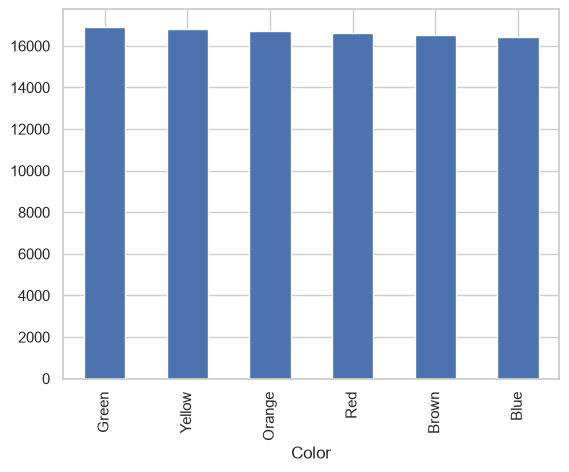

In [27]:
color_agg_mnm_pdf = color_agg_mnm.toPandas()
color_agg_mnm_pdf.plot.bar(x="Color", y="count", legend=False)

Text(0.5, 1.0, 'M&M Color Distribution')

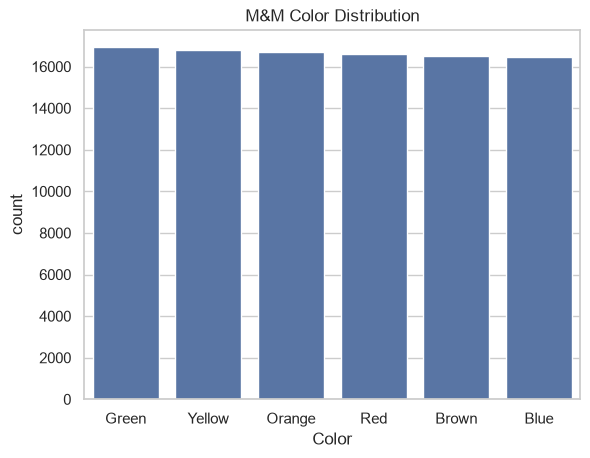

In [26]:
sns.set_theme(style="whitegrid")
sns.barplot(x="Color", y="count", data=color_agg_mnm_pdf)
plt.title("M&M Color Distribution")
